# 06 - Modeling & Evaluation

## 1. Load Data

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib

from src.config import load_config
from src.utils import setup_logging, ensure_dir
from src.modeling import nested_cv_pipeline
from src.evaluation import (
    compute_metrics, plot_predictions_vs_obs,
    plot_feature_importance, plot_shap_summary,
    results_summary_table,
)

logger = setup_logging()
config = load_config()
output_dir = config['data']['output_dir']
ensure_dir('../models')
ensure_dir('../figures')

AGGREGATION_MODE = config['aggregation']['mode']
print(f"Aggregation mode: {AGGREGATION_MODE}")
print(f"\nModel switches:")
for name, enabled in config['modeling']['models'].items():
    status = "ENABLED" if enabled else "disabled"
    print(f"  {name}: {status}")

Aggregation mode: monthly

Model switches:
  RandomForest: ENABLED
  LightGBM: ENABLED
  XGBoost: ENABLED
  ElasticNet: ENABLED
  CatBoost: disabled
  Stacking: ENABLED


In [2]:
import re

# Load engineered features (all — feature selection runs inside CV)
df = pd.read_parquet(f'{output_dir}/engineered_features_{AGGREGATION_MODE}.parquet')

# Prepare X with all numeric features, y, groups
exclude = ['field_key', 'protein_pct', 'yield_bu_ac', 'county', 'state',
           'centroid_lat', 'centroid_lon']
feat_cols = [c for c in df.columns
             if c not in exclude and df[c].dtype in ['int64', 'float64']]

# --- Raw features only (drop derived/engineered) ---
use_raw_only = True

if use_raw_only:
    # Period prefixes for all aggregation modes
    _P = (r'(?:bw|mo|cp[1-5]'
          r'|jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec'
          r'|tillering|stem_elongation|booting|heading_anthesis|grain_filling|maturity)')
    derived_patterns = [
        rf'_(change|ratio|roc)_{_P}',  # Temporal derivatives (all modes)
        r'_div_',             # Band ratios (B8_div_B4 etc.)
        r'_x_',              # All interaction terms (VI×VI, VI×soil, VI×meteo)
        r'_aridity_idx',      # Agronomic: aridity index
        r'_water_deficit',    # Agronomic: water deficit
        r'_heat_stress',      # Agronomic: heat stress
        r'^pheno_',           # Phenological features
        r'_seasonal_cv$',     # Seasonal aggregate: CV
        r'_seasonal_range$',  # Seasonal aggregate: range
        r'_seasonal_slope$',  # Seasonal aggregate: slope
    ]
    is_derived = lambda c: any(re.search(p, c) for p in derived_patterns)
    n_before = len(feat_cols)
    feat_cols = [c for c in feat_cols if not is_derived(c)]
    print(f"Raw features only: {n_before} -> {len(feat_cols)} (dropped {n_before - len(feat_cols)} derived)")

X = df[feat_cols].copy()
y = df['protein_pct'].values
groups = df['field_key'].values

print(f"Features (input to CV): {X.shape[1]}")
print(f"Samples: {len(y)}")
print(f"Groups: {len(np.unique(groups))}")
print(f"Feature selection will run INSIDE each outer fold (no leakage)")

Raw features only: 3936 -> 1981 (dropped 1955 derived)
Features (input to CV): 1981
Samples: 228
Groups: 228
Feature selection will run INSIDE each outer fold (no leakage)


## 1b. GCVI Fall/Spring Peak Ratio vs Protein

Exploratory analysis: does the ratio of fall (tillering) GCVI peak to spring
(heading) GCVI peak correlate with grain protein across the full training set?

In [ ]:
import plotly.graph_objects as go

# Load raw spectral time series and detected peaks
spectral_raw = pd.read_parquet(f'{output_dir}/spectral_raw.parquet')
spectral_raw['date'] = pd.to_datetime(spectral_raw['date'])

peak_df = pd.read_csv(f'{output_dir}/peak_days.csv')
peak_df['peak_date'] = pd.to_datetime(peak_df['peak_date'])
peak_df['field_key'] = peak_df['field_key'].astype(str)

# Protein per field from engineered features
protein_by_field = df.groupby('field_key')['protein_pct'].mean()

# Compute fall/spring GCVI peak ratio for every field
peak_ratio_records = []

for fk in spectral_raw['field_key'].unique():
    fk_str = str(fk)
    grp = spectral_raw[spectral_raw['field_key'] == fk].copy()

    peak_row = peak_df[peak_df['field_key'] == fk_str]
    if len(peak_row) == 0:
        continue
    peak_date = pd.Timestamp(peak_row.iloc[0]['peak_date'])

    # Spring window: +/- 15 days around peak
    spring_window = grp[(grp['date'] >= peak_date - pd.Timedelta(days=15)) &
                        (grp['date'] <= peak_date + pd.Timedelta(days=15))]
    spring_peak_gcvi = spring_window['GCVI'].max()

    # Fall window: Oct 1 – Jan 31 (tillering period for winter wheat)
    fall_window = grp[(grp['date'] >= '2024-10-01') & (grp['date'] <= '2025-01-31')]
    fall_peak_gcvi = fall_window['GCVI'].max() if len(fall_window) > 0 else np.nan

    protein_val = protein_by_field.get(fk_str, np.nan)

    peak_ratio_records.append({
        'field_key': fk_str,
        'fall_peak_gcvi': fall_peak_gcvi,
        'spring_peak_gcvi': spring_peak_gcvi,
        'peak_ratio': fall_peak_gcvi / spring_peak_gcvi if spring_peak_gcvi > 0 else np.nan,
        'protein_pct': protein_val
    })

peak_ratio_df = pd.DataFrame(peak_ratio_records).dropna()
corr = peak_ratio_df['peak_ratio'].corr(peak_ratio_df['protein_pct'])

print(f"Fields with valid ratio: {len(peak_ratio_df)}")
print(f"Pearson r = {corr:.3f}")

# --- Scatter plot ---
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=peak_ratio_df['peak_ratio'],
    y=peak_ratio_df['protein_pct'],
    mode='markers+text',
    marker=dict(size=10, color='steelblue', opacity=0.7,
                line=dict(color='black', width=0.5)),
    text=['F' + str(fk) for fk in peak_ratio_df['field_key']],
    textposition='top right', textfont=dict(size=8),
    hovertemplate=(
        'Field %{text}<br>'
        'Fall/Spring ratio: %{x:.2f}<br>'
        'Protein: %{y:.2f}%<extra></extra>'
    ),
    showlegend=False
))

# Trend line
z = np.polyfit(peak_ratio_df['peak_ratio'], peak_ratio_df['protein_pct'], 1)
x_line = np.linspace(peak_ratio_df['peak_ratio'].min() - 0.02,
                     peak_ratio_df['peak_ratio'].max() + 0.02, 50)
fig.add_trace(go.Scatter(
    x=x_line, y=np.polyval(z, x_line),
    mode='lines', line=dict(color='red', dash='dash', width=1.5),
    name=f'r = {corr:.2f}'
))

fig.update_layout(
    title=f'GCVI Fall/Spring Peak Ratio vs Protein — Full Dataset (r = {corr:.2f}, n = {len(peak_ratio_df)})',
    xaxis_title='Fall Peak GCVI / Spring Peak GCVI',
    yaxis_title='Protein (%)',
    width=800, height=600,
    template='plotly_white'
)
fig.show()

print(peak_ratio_df[['field_key', 'fall_peak_gcvi', 'spring_peak_gcvi', 'peak_ratio', 'protein_pct']]
      .sort_values('peak_ratio').to_string(index=False))

## 2. Run Nested Cross-Validation

In [ ]:
cv_results = nested_cv_pipeline(X, y, groups, config, run_feature_selection=True)

print(f"\nNested CV complete!")
print(f"Folds: {len(cv_results['fold_results'])}")

# Show feature selection stability across folds
if 'per_fold_features' in cv_results:
    from collections import Counter
    all_feats = [f for fold in cv_results['per_fold_features'] for f in fold]
    feat_counts = Counter(all_feats)
    n_folds = len(cv_results['per_fold_features'])
    
    print(f"\nFeature stability across {n_folds} folds:")
    for n in range(n_folds, 0, -1):
        count = sum(1 for f, c in feat_counts.items() if c == n)
        if count > 0:
            print(f"  Selected in {n}/{n_folds} folds: {count} features")
    
    # Features selected in ALL folds (most stable)
    stable_features = [f for f, c in feat_counts.items() if c == n_folds]
    print(f"\nStable features (all {n_folds} folds): {len(stable_features)}")
    for f in sorted(stable_features):
        print(f"  {f}")

17:27:00 | INFO    | Nested CV: 5 outer folds, models: ['RandomForest', 'LightGBM', 'XGBoost', 'ElasticNet'] + Stacking
17:27:00 | INFO    | Unsupervised prescreening: variance filter (threshold=1.00e-06): 1981 → 1972 features
17:27:01 | INFO    | Unsupervised prescreening: collinearity filter (threshold=0.90): 1972 → 585 features
17:27:01 | INFO    | Unsupervised prescreening complete: 1981 → 585 features
17:27:01 | INFO    | Outer CV: StratifiedKFold (shuffle=True, 5 splits, 5 protein bins)
17:27:01 | INFO    | --- Fold 1/5 ---
17:27:01 | INFO    | Feature selection pipeline: 585 input features, 182 samples
17:27:01 | INFO    | Prescreening: disabled
17:27:19 | INFO    | Boruta: 16 confirmed, 2 tentative → 18 selected features
17:27:19 | INFO    | After Boruta: 18 features
17:27:19 | INFO    | Feature selection complete: 585 → 18 features
17:27:19 | INFO    |   Feature selection: 585 → 18 features
17:27:32 | INFO    |   RandomForest — best params: {'n_estimators': 500, 'min_samples_l

## 3. Results Summary

In [4]:
summary_df = results_summary_table(cv_results['summary'])
print(f"\n{'=' * 80}")
print("MODEL PERFORMANCE SUMMARY (mean +/- std across folds)")
print(f"{'=' * 80}")
print(summary_df.to_string(index=False))


MODEL PERFORMANCE SUMMARY (mean +/- std across folds)
       Model  R2_mean  R2_std              R2  CCC_mean  CCC_std             CCC  RMSE_mean  RMSE_std            RMSE  RRMSE_mean  RRMSE_std            RRMSE  MBE_mean  MBE_std              MBE  PLA_mean  PLA_std             PLA  PLP_mean  PLP_std             PLP  KGE_mean  KGE_std             KGE
RandomForest   0.1547  0.1226 0.1547 ± 0.1226    0.3645   0.0642 0.3645 ± 0.0642     1.2210    0.0842 1.2210 ± 0.0842     10.0578     0.7415 10.0578 ± 0.7415   -0.0360   0.1984 -0.0360 ± 0.1984    8.4877   0.9705 8.4877 ± 0.9705    5.2980   0.9582 5.2980 ± 0.9582    0.2778   0.0640 0.2778 ± 0.0640
    LightGBM   0.0837  0.1924 0.0837 ± 0.1924    0.3521   0.0550 0.3521 ± 0.0550     1.2662    0.0737 1.2662 ± 0.0737     10.4288     0.6424 10.4288 ± 0.6424   -0.0258   0.1775 -0.0258 ± 0.1775    8.4130   0.9528 8.4130 ± 0.9528    6.0062   1.3737 6.0062 ± 1.3737    0.2813   0.0542 0.2813 ± 0.0542
     XGBoost   0.1241  0.1446 0.1241 ± 0.1446   

## 4. Predictions vs Observations

In [ ]:
model_names = [m for m in cv_results['summary'].keys() if cv_results['summary'][m]]
n_models = len(model_names)
n_cols = min(3, n_models)
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
if n_models == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Prediction interval options: "rmse", "95ci", "10pct", "20pct", or None
PREDICTION_INTERVAL = "rmse"  # Shows ±RMSE band around 1:1 line

for i, model_name in enumerate(model_names):
    metrics = {k: np.mean(v) for k, v in cv_results['summary'][model_name].items() if v}
    
    # Collect OOF predictions for this model
    oof = cv_results['oof_predictions']
    pred_col = f'y_pred_{model_name}'
    if pred_col in oof.columns:
        y_true_oof = oof['y_true'].values
        y_pred_oof = oof[pred_col].values
        mask = np.isfinite(y_true_oof) & np.isfinite(y_pred_oof)
        plot_predictions_vs_obs(
            y_true_oof[mask], y_pred_oof[mask], 
            model_name, axes[i], metrics,
            prediction_interval=PREDICTION_INTERVAL
        )
    else:
        axes[i].set_title(model_name)
        axes[i].text(0.5, 0.5, 'No OOF predictions', ha='center', va='center', transform=axes[i].transAxes)

for j in range(len(model_names), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Model Performance ({AGGREGATION_MODE})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'../figures/06_predictions_vs_obs_{AGGREGATION_MODE}.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance

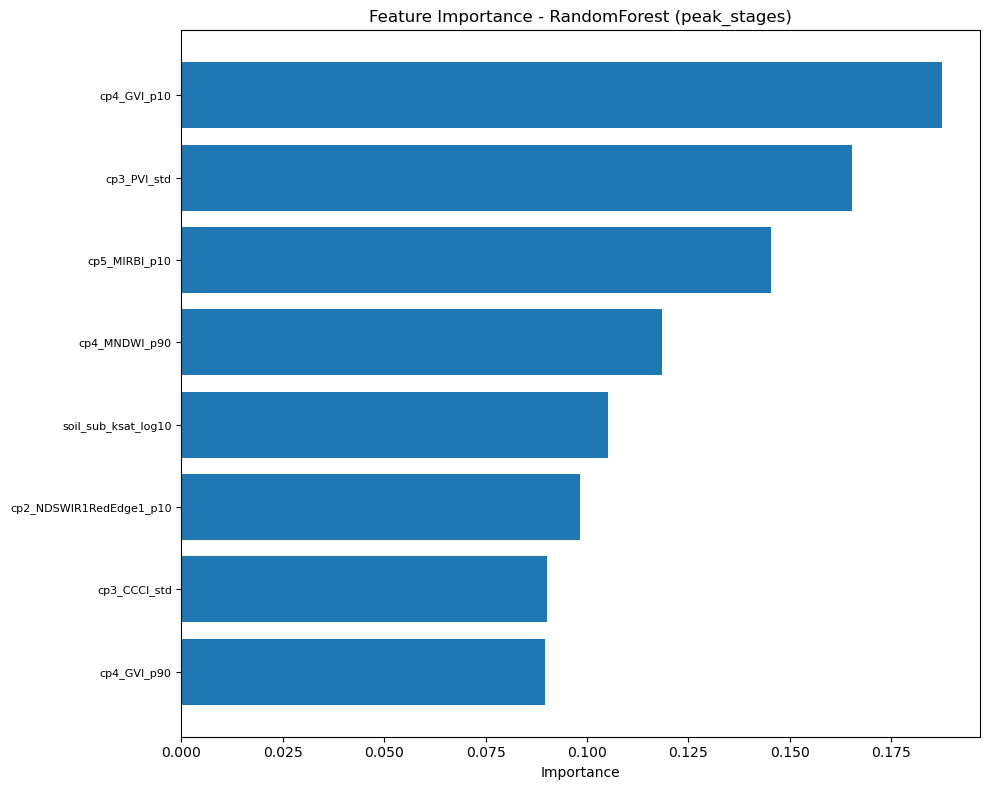

In [11]:
# Get feature importance from the best fold of the best model (excluding Ensemble/Stacking)
# Filter out Ensemble and Stacking as they don't have simple feature importances
base_models = {k: v for k, v in cv_results['summary'].items() 
               if k not in ['Ensemble', 'Stacking'] and v.get('RMSE')}

if base_models:
    best_model_name = min(base_models.items(), 
                          key=lambda x: np.mean(x[1].get('RMSE', [999])))[0]

    # Find the best fold for this model
    best_fold_idx = 0
    best_r2 = -999
    for i, fold in enumerate(cv_results['fold_results']):
        if best_model_name in fold:
            r2 = fold[best_model_name].get('test_metrics', {}).get('R2', -999)
            if r2 > best_r2:
                best_r2 = r2
                best_fold_idx = i

    best_fold = cv_results['fold_results'][best_fold_idx]
    
    # Use per-fold features if available, otherwise global feature_names
    if 'per_fold_features' in cv_results:
        fold_feature_names = cv_results['per_fold_features'][best_fold_idx]
    else:
        fold_feature_names = cv_results['feature_names']
    
    if best_model_name in best_fold and best_fold[best_model_name].get('fitted_model') is not None:
        model = best_fold[best_model_name]['fitted_model']
        
        if hasattr(model, 'feature_importances_'):
            fig, ax = plt.subplots(figsize=(10, 8))
            plot_feature_importance(
                model.feature_importances_,
                fold_feature_names,
                top_n=25,
                title=f'Feature Importance - {best_model_name} ({AGGREGATION_MODE})',
                ax=ax,
            )
            plt.tight_layout()
            plt.savefig(f'../figures/06_feature_importance_{AGGREGATION_MODE}.png', dpi=150, bbox_inches='tight')
            plt.show()
        elif hasattr(model, 'coef_'):
            # For linear models like ElasticNet
            fig, ax = plt.subplots(figsize=(10, 8))
            coef_abs = np.abs(model.coef_)
            plot_feature_importance(
                coef_abs,
                fold_feature_names,
                top_n=25,
                title=f'Feature Coefficients (abs) - {best_model_name} ({AGGREGATION_MODE})',
                ax=ax,
            )
            plt.tight_layout()
            plt.savefig(f'../figures/06_feature_importance_{AGGREGATION_MODE}.png', dpi=150, bbox_inches='tight')
            plt.show()
        else:
            print(f"{best_model_name} does not have feature_importances_ or coef_ attribute")
    else:
        print(f"No fitted model available for {best_model_name}")
else:
    print("No base models with RMSE metrics available")

## 6. Save Results

In [ ]:
# Save summary
summary_dict = {}
for model_name, metrics in cv_results['summary'].items():
    summary_dict[model_name] = {k: {'mean': float(np.mean(v)), 'std': float(np.std(v, ddof=1)) if len(v) > 1 else 0.0} for k, v in metrics.items() if v}

with open(f'../models/results_{AGGREGATION_MODE}.json', 'w') as f:
    json.dump(summary_dict, f, indent=2)

# Save OOF predictions
cv_results['oof_predictions'].to_csv(f'../models/oof_predictions_{AGGREGATION_MODE}.csv', index=False)

# Save best model
if best_model_name in best_fold and best_fold[best_model_name]['fitted_model'] is not None:
    joblib.dump(best_fold[best_model_name]['fitted_model'], 
                f'../models/{best_model_name}_best_{AGGREGATION_MODE}.joblib')

print(f"Saved results to models/results_{AGGREGATION_MODE}.json")
print(f"Saved OOF predictions to models/oof_predictions_{AGGREGATION_MODE}.csv")